## Packages and env setup

In [1]:
# %pip install datasets

In [2]:
# pip install matplotlib

## Constants

In [3]:
from transformers import AutoTokenizer

In [ ]:
model_name = 'tiiuae/falcon-7b-instruct'
dataset_name = 'tatsu-lab/alpaca'

batch_size = 8
epochs = 1
lr = 1e-5

## Tokenizer

In [5]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

/venv/main/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## Load data

In [6]:
from datasets import load_dataset
dataset = load_dataset(dataset_name)

In [7]:
dataset

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 52002
    })
})

In [ ]:
split = dataset["train"].train_test_split(test_size=0.2)

train_dataset = split["train"]
val_dataset = split["test"]

In [9]:
train_dataset[:4]

{'instruction': ['Change the second noun in the sentence to make it a valid sentence.',
  'Create a machine learning algorithm to detect anomalous activity in a network.',
  'Explain the difference between parallel and perpendicular lines.',
  'State the main differences between a tornado and a hurricane.'],
 'input': ['This car created', '', '', ''],
 'output': ['This car was created',
  'A machine learning algorithm for detecting anomalous activity in a network can be created by first collecting network performance data, such as system logs and network traffic. This data can then be used to detect anomalies, such as unauthorized network connections or suspicious traffic flows. Feature engineering is then performed to create a machine learning dataset with meaningful labels and values, based on the collected data. A machine learning model, such as a Support Vector Machine (SVM) or an artificial neural network, is trained on the dataset to create an algorithm that can detect and classi

In [10]:
REWARD_TOKEN_ID = tokenizer.eos_token_id

In [11]:
REWARD_TOKEN_ID

50256

## Tokenization

In [12]:
def tokenize(batch):

    texts = []

    for ins, inp, out in zip(
        batch["instruction"],
        batch["input"],
        batch["output"]
    ):
        text = f"Instruction: {ins}\nInput: {inp}\nResponse: {out}"
        texts.append(text)

    tokenized = tokenizer(
        texts,
        padding=False,
        truncation=True,
        max_length=512
    )

    return tokenized

In [13]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True,
    remove_columns=train_dataset.column_names
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True,
    remove_columns=val_dataset.column_names
)

Map:   0%|          | 0/49401 [00:00<?, ? examples/s]

Map:   0%|          | 0/2601 [00:00<?, ? examples/s]

In [14]:
train_dataset.set_format(type="torch")
val_dataset.set_format(type="torch")

## Data loader

In [15]:
from transformers import (
    AutoTokenizer,
    AutoModel,
    DataCollatorWithPadding
)
from torch.utils.data import DataLoader


In [16]:
data_collator = DataCollatorWithPadding(tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=data_collator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    collate_fn=data_collator
)

In [17]:
# tokenized_dataset_train = tokenized_dataset_train.filter(lambda x: len(x['input_ids']) > 5)
# tokenized_dataset_val = tokenized_dataset_val.filter(lambda x: len(x['input_ids']) > 5)

In [18]:
# len(tokenized_dataset_train), len(tokenized_dataset_val)

In [19]:
import torch

In [20]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

## Reward Model

In [21]:

from torch import nn
import numpy as np
from transformers import AutoModelForCausalLM

class RewardModel(nn.Module):
  def __init__(self, model_name):
      super().__init__()

      self.transformer = AutoModel.from_pretrained(model_name)

      hidden_size = self.transformer.config.hidden_size

      self.reward_head = nn.Linear(hidden_size, 1)

  def forward(self, input_ids, attention_mask):

      outputs = self.transformer(
          input_ids=input_ids,
          attention_mask=attention_mask
      )

      hidden = outputs.last_hidden_state

      last_token = hidden[:, -1, :]

      reward = self.reward_head(last_token)

      return reward.squeeze(-1)

In [22]:
model = RewardModel(model_name).to(device)

/venv/main/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [23]:
class GPT2RewardModel(nn.Module):

    def __init__(self, model_name):
        super().__init__()

        self.transformer = AutoModel.from_pretrained(model_name)

        hidden_size = self.transformer.config.hidden_size

        self.reward_head = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):

        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden_states = outputs.last_hidden_state

        last_token = hidden_states[:, -1, :]

        reward = self.reward_head(last_token)

        return reward.squeeze(-1)

In [24]:
model = GPT2RewardModel(model_name).to(device)

## Optimizer

In [25]:
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

criterion = nn.MSELoss()

## Validation

In [26]:
def validate():

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for batch in val_loader:

            batch = {k: v.to(device) for k, v in batch.items()}

            rewards = model(
                batch["input_ids"],
                batch["attention_mask"]
            )

            targets = torch.ones_like(rewards)

            loss = criterion(rewards, targets)

            total_loss += loss.item()

    avg_val_loss = total_loss / len(val_loader)
    print("Validation Loss:", avg_val_loss)
    return avg_val_loss

In [27]:
len(train_loader)

6176

## Training

In [28]:
import matplotlib.pyplot as plt

train_losses = []
val_losses = []

In [29]:
for epoch in range(epochs):

    model.train()
    epoch_loss = 0
    batch_count = 0

    for i, batch in enumerate(train_loader, 1):
        batch = {k: v.to(device) for k, v in batch.items()}

        rewards = model(
            batch["input_ids"],
            batch["attention_mask"]
        )

        targets = torch.ones_like(rewards)

        loss = criterion(rewards, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        batch_count += 1

        print("loss:", loss.item())
        if i % 100 == 0:
            print(f"Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.4f}")

    # Average training loss for the epoch
    avg_train_loss = epoch_loss / batch_count
    train_losses.append(avg_train_loss)

    val_loss = validate()
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}")

loss: 5.364698886871338
loss: 3.2586793899536133
loss: 4.187937259674072
loss: 1.8936069011688232
loss: 3.1771485805511475
loss: 2.440751314163208
loss: 2.449605703353882
loss: 1.216551423072815
loss: 1.5744538307189941
loss: 0.9218075275421143
loss: 0.8048433661460876
loss: 0.5763013958930969
loss: 0.920428454875946
loss: 1.3105111122131348
loss: 0.4307437539100647
loss: 1.0796153545379639
loss: 3.1143572330474854
loss: 0.49890896677970886
loss: 0.7756457328796387
loss: 0.7261340618133545
loss: 1.2320661544799805
loss: 0.20785348117351532
loss: 0.31443357467651367
loss: 0.18223364651203156
loss: 0.4917319416999817
loss: 0.19283755123615265
loss: 0.2677780091762543
loss: 0.2645122706890106
loss: 0.7680081129074097
loss: 0.33799201250076294
loss: 1.1423518657684326
loss: 0.4317399859428406
loss: 0.22264620661735535
loss: 0.23977580666542053
loss: 0.537431001663208
loss: 0.26355746388435364
loss: 0.34768182039260864
loss: 0.12000252306461334
loss: 0.37284159660339355
loss: 0.125081583857

## Visualization

In [30]:
print(train_losses, val_losses)

[0.023732890517408713] [0.000349282938538407]


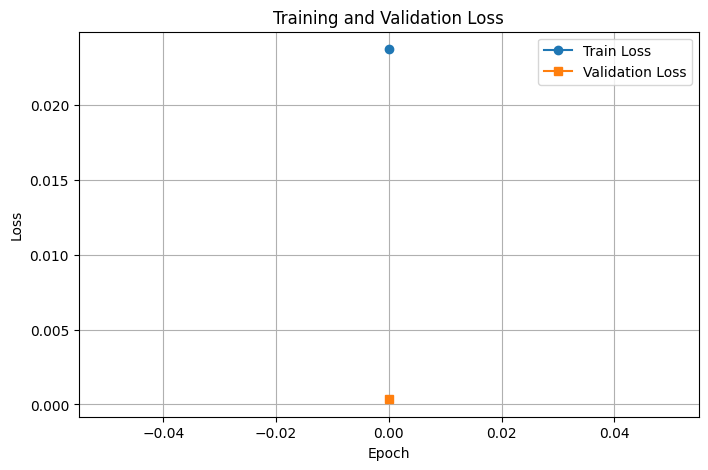

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='s', label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

In [32]:
# from torch.utils.data import DataLoader
# from transformers import DataCollatorWithPadding

# tokenizer.pad_token = tokenizer.eos_token
# data_collator = DataCollatorWithPadding(tokenizer)
# dataloader_param = {
#     "batch_size": 64,
#     "collate_fn": data_collator,
#     "shuffle": True
# }
# train_dataloader = DataLoader(tokenized_dataset_train, **dataloader_param)
# val_dataloader = DataLoader(tokenized_dataset_val, **dataloader_param)

In [33]:
# batch = next(iter(train_dataloader))
# print(batch.keys())

In [34]:
# print(batch["input_ids"][1])

In [35]:
# print(tokenizer.decode(batch['input_ids'][1]))

In [36]:
# batch['attention_mask'][1].nonzero()[-1]

In [37]:
# outputs = model(batch['input_ids'], batch['attention_mask'])

In [38]:
# print(outputs.shape)

In [39]:
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
# criterion = nn.BCELoss()
# num_epochs = 1

In [40]:
# device

In [41]:
# print(inputs["score"].min(), inputs["score"].max())


In [42]:
# model.to(device)

In [43]:
# def validate():
#   model.eval()
#   total_loss=0.0
#   for i, batch in enumerate(val_dataloader):
#     inputs = batch.to(device)
#     model_inputs = {
#         "input_ids": inputs["input_ids"],
#         "attention_mask": inputs["attention_mask"]
#     }
#     with torch.no_grad():
#       scores = model(**model_inputs)
#       batch_indices = torch.arange(scores.shape[0])
#       score = scores[batch_indices, inputs["score_index"]]
#       target = inputs["score"]
#       loss = criterion(score, target)
#     total_loss += loss.item()
#   print(f'validation loss: {total_loss/len(val_dataloader)}')

In [44]:
# model.to(device)

# validate()
# for epoch in range(num_epochs):
#     model.train()
#     for i, batch in enumerate(train_dataloader):
#         inputs = batch.to(device)
#         model_inputs = {
#             'input_ids': inputs['input_ids'],
#             'attention_mask': inputs['attention_mask']
#         }
#         scores = model(**model_inputs)
#         batch_indices = torch.arange(scores.shape[0])
#         score = scores[batch_indices, inputs['score_index']]
#         target = inputs['score']
#         loss = criterion(score, target)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         print(loss.item())
#     validate()

## Save Model

In [52]:
saving_format = f'{model_name.split('/')[-1]}-{dataset_name.split('/')[-1]}'

In [60]:
# torch.save(model.state_dict(), f'reward_model-{saving_format}.pt')
torch.save(model.state_dict(), 'rewardmodel.pt')

In [54]:
validate()

Validation Loss: 0.000349282938538407


0.000349282938538407

In [55]:
sample_text = "Instruction: Write a short poem about AI.\nInput: None\nResponse: AI learns and grows each day, making the world bright in every way."

# Tokenize
inputs = tokenizer(
    sample_text,
    return_tensors="pt",   # returns batch dimension
    truncation=True,
    max_length=512,
    padding=True           # use pad token
)

# Move to device
inputs = {k: v.to(device) for k, v in inputs.items()}

In [56]:
model.eval()
with torch.no_grad():
    reward = model(inputs["input_ids"], inputs["attention_mask"])

In [57]:
print("Reward score:", reward.item())

Reward score: 1.0379317998886108


In [51]:
# from sklearn.metrics import confusion_matrix
# model.eval()

# all_predictions = []
# all_labels = []

# for i, batch in enumerate(val_dataloader):
#   input = batch.to(device)
#   model_inputs = {
#       "input_ids": input["input_ids"],
#       "attention_mask": input["attention_mask"]
#   }
#   with torch.no_grad():
#     scores = model(**model_inputs)
#     batch_indices = torch.arange(scores.shape[0])
#     score = scores[batch_indices, inputs["score_index"]]
#     target = inputs["score"]
#   predictions = (score > 0.5).int()

#   all_predictions.extend(predictions.cpu().numpy())
#   all_labels.extend(target.cpu().numpy())

# confusion_matrix(all_labels, all_predictions)